# 🛡️ Adversarial Robustness Evaluation of Image Classification Models

## 📋 Problem Statement

This notebook implements an **automated pipeline** to evaluate the adversarial robustness of image classification models. We will:

1. Load a pre-trained model and CIFAR-10 dataset
2. Implement adversarial attacks (FGSM and PGD)
3. Analyze the impact on model performance
4. Visualize results and provide insights
5. (Optional) Explore mitigation techniques

**Author:** Sathyanarayan Rao  


In [1]:
# ============================================================
# STEP 0: Installation & Setup
# ============================================================
# Install the Adversarial Robustness Toolbox (ART)
# ART is a library for adversarial machine learning with 
# ready-to-use attack and defense implementations
# ============================================================

!pip install adversarial-robustness-toolbox --quiet

print("✅ Installation complete!")

✅ Installation complete!


---
## 📚 Step 1: Import Libraries & Load Dataset

We'll import all necessary libraries and load the CIFAR-10 dataset for our experiments.

**Libraries used:**
- **PyTorch**: Deep learning framework
- **ART**: Adversarial Robustness Toolbox for attacks
- **NumPy/Matplotlib**: Data processing and visualization

Purpose of these libraries: 

- PyTorch / torchvision — model + dataset utilities.
- ART (Adversarial Robustness Toolbox) — provides attacks (FGSM, PGD), wrappers to connect - - PyTorch/TensorFlow models, and utilities for evaluation.
- Matplotlib / NumPy / PIL — plotting and image handling.
- ResNet (residual network) — short paragraph: skip connections let gradients flow; ResNet18  compact 18-layer variant.


In [2]:
# ============================================================
# Import Required Libraries
# ============================================================

import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torchvision import models
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# ART imports for adversarial attacks
from art.attacks.evasion import FastGradientMethod, ProjectedGradientDescent
from art.estimators.classification import PyTorchClassifier

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🔧 Using device: {device}")
print(f"✅ All libraries imported successfully!")

🔧 Using device: cuda
✅ All libraries imported successfully!


In [3]:
# ============================================================
# Load CIFAR-10 Dataset
# ============================================================
# CIFAR-10: 60,000 32x32 color images in 10 classes
# Classes: airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck
# ============================================================

# Define transforms (normalize using ImageNet stats for pretrained models)
transform = transforms.Compose([
    transforms.Resize(224),  # Resize to 224x224 for pretrained models
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                       std=[0.229, 0.224, 0.225])
])

# Load CIFAR-10 test set
test_dataset = torchvision.datasets.CIFAR10(
    root='./data', 
    train=False, 
    download=True, 
    transform=transform
)

# Create data loader
test_loader = torch.utils.data.DataLoader(
    test_dataset, 
    batch_size=64, 
    shuffle=False
)

# CIFAR-10 class names
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 
               'dog', 'frog', 'horse', 'ship', 'truck']

print(f"✅ CIFAR-10 loaded successfully!")
print(f"📊 Test set size: {len(test_dataset)} images")
print(f"🏷️  Classes: {class_names}")

✅ CIFAR-10 loaded successfully!
📊 Test set size: 10000 images
🏷️  Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


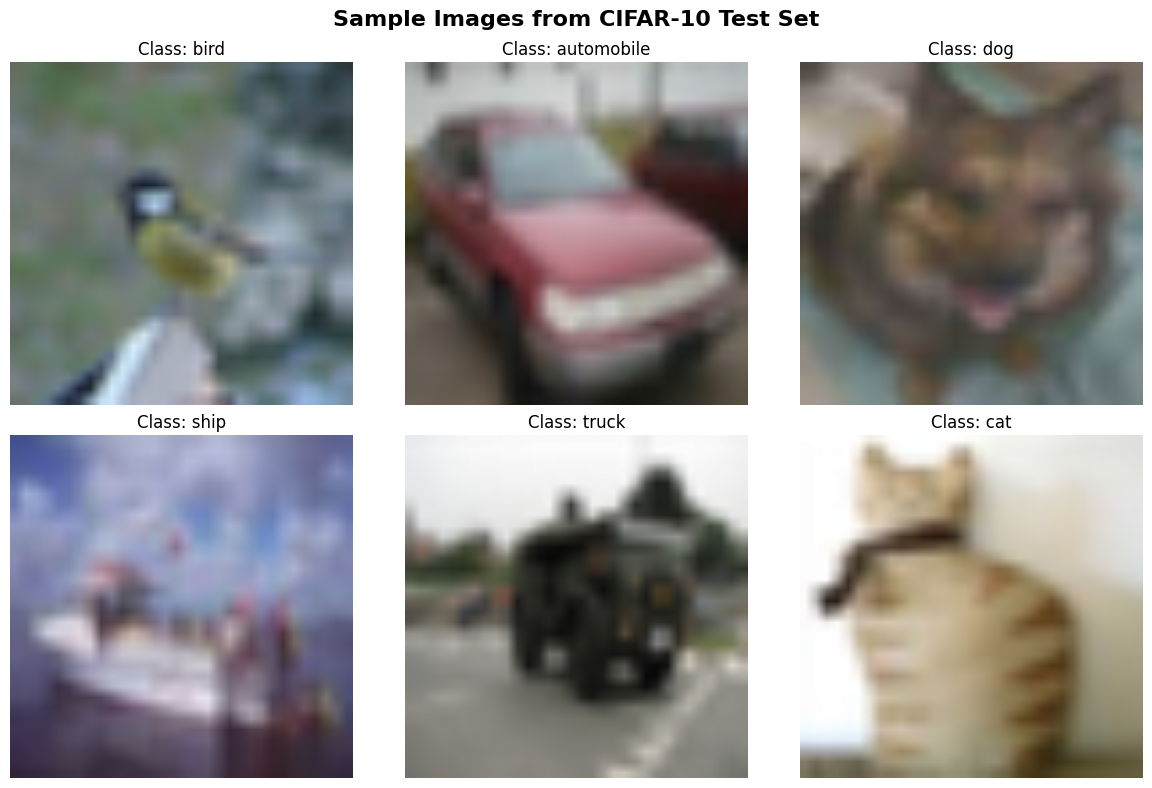

✅ Sample images displayed successfully!


In [4]:
# ============================================================
# Visualize Sample Images from CIFAR-10
# ============================================================

# Function to denormalize images for visualization
def denormalize(tensor):
    """Convert normalized tensor back to [0,1] range for display"""
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return tensor * std + mean

# Get 6 random samples
indices = np.random.choice(len(test_dataset), 6, replace=False)

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
fig.suptitle('Sample Images from CIFAR-10 Test Set', fontsize=16, fontweight='bold')

for idx, ax in enumerate(axes.flat):
    img, label = test_dataset[indices[idx]]
    
    # Denormalize and convert to displayable format
    img_display = denormalize(img).permute(1, 2, 0).numpy()
    img_display = np.clip(img_display, 0, 1)
    
    ax.imshow(img_display)
    ax.set_title(f'Class: {class_names[label]}', fontsize=12)
    ax.axis('off')

plt.tight_layout()
plt.show()

print("✅ Sample images displayed successfully!")

---
## 🧠 Step 2: Load Pre-trained Image Classification Model

We'll use **ResNet-18**, a popular convolutional neural network pre-trained on ImageNet.

**Why ResNet-18?**
- Lightweight yet powerful (11M parameters)
- Good balance between accuracy and speed
- Widely used in research and industry
- Pre-trained weights available in PyTorch

We'll adapt it for CIFAR-10's 10 classes.

In [5]:
# ============================================================
# Load Pre-trained ResNet-18 Model & Fine-tune for CIFAR-10
# ============================================================
# ResNet-18 is pre-trained on ImageNet (1000 classes)
# We'll modify the final layer and train it on CIFAR-10
# ============================================================

import torch.optim as optim

# Load pre-trained ResNet-18
model = models.resnet18(pretrained=True)

# Modify the final fully connected layer for CIFAR-10 (10 classes)
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 10)

# Move model to GPU
model = model.to(device)

# Load training data for fine-tuning
train_dataset = torchvision.datasets.CIFAR10(
    root='./data', 
    train=True, 
    download=True, 
    transform=transform
)

train_loader = torch.utils.data.DataLoader(
    train_dataset, 
    batch_size=128, 
    shuffle=True,
    num_workers=2
)

# Setup training
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("✅ ResNet-18 loaded successfully!")
print(f"📊 Model architecture: ResNet-18")
print(f"🎯 Output classes: 10 (adapted for CIFAR-10)")
print(f"💾 Total parameters: {sum(p.numel() for p in model.parameters()):,}")
print("\n🔄 Training model on CIFAR-10 (this will take a few minutes)...")
print("📊 Training for 3 epochs...\n")

# Training loop
model.train()
for epoch in range(3):
    running_loss = 0.0
    correct = 0
    total = 0
    
    for i, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        # Print progress every 100 batches
        if (i + 1) % 100 == 0:
            print(f"Epoch [{epoch+1}/3], Step [{i+1}/{len(train_loader)}], "
                  f"Loss: {running_loss/100:.4f}, "
                  f"Accuracy: {100*correct/total:.2f}%")
            running_loss = 0.0

model.eval()
print("\n✅ Training complete! Model ready for evaluation.")

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


✅ ResNet-18 loaded successfully!
📊 Model architecture: ResNet-18
🎯 Output classes: 10 (adapted for CIFAR-10)
💾 Total parameters: 11,181,642

🔄 Training model on CIFAR-10 (this will take a few minutes)...
📊 Training for 3 epochs...

Epoch [1/3], Step [100/391], Loss: 0.6912, Accuracy: 76.29%
Epoch [1/3], Step [200/391], Loss: 0.4465, Accuracy: 80.57%
Epoch [1/3], Step [300/391], Loss: 0.4012, Accuracy: 82.55%
Epoch [2/3], Step [100/391], Loss: 0.2560, Accuracy: 91.44%
Epoch [2/3], Step [200/391], Loss: 0.2651, Accuracy: 91.12%
Epoch [2/3], Step [300/391], Loss: 0.2689, Accuracy: 91.06%
Epoch [3/3], Step [100/391], Loss: 0.1562, Accuracy: 94.75%
Epoch [3/3], Step [200/391], Loss: 0.1616, Accuracy: 94.68%
Epoch [3/3], Step [300/391], Loss: 0.1909, Accuracy: 94.26%

✅ Training complete! Model ready for evaluation.


In [6]:
# ============================================================
# Evaluate Model on Clean (Original) Images
# ============================================================
# Baseline accuracy before adversarial attacks
# ============================================================

def evaluate_model(model, data_loader, device):
    """
    Evaluate model accuracy on a dataset
    
    Args:
        model: PyTorch model
        data_loader: DataLoader for the dataset
        device: cuda or cpu
    
    Returns:
        accuracy: Percentage of correctly classified images
    """
    model.eval()
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    accuracy = 100 * correct / total
    return accuracy

# Evaluate on clean images
clean_accuracy = evaluate_model(model, test_loader, device)

print(f"🎯 Clean Accuracy (baseline): {clean_accuracy:.2f}%")
print(f"📊 Correctly classified: {int(clean_accuracy * 100)}/10000 images")
print("✅ Baseline evaluation complete!")

🎯 Clean Accuracy (baseline): 88.15%
📊 Correctly classified: 8815/10000 images
✅ Baseline evaluation complete!


---
## ⚔️ Step 3: Adversarial Attacks Implementation

### What are Adversarial Attacks?

Adversarial attacks add small, carefully crafted perturbations to images that are **imperceptible to humans** but cause machine learning models to misclassify them.

### Attacks We'll Implement:

#### 1️⃣ **FGSM (Fast Gradient Sign Method)**
- **How it works**: Uses the gradient of the loss function with respect to the input
- **Perturbation**: Single-step attack that moves in the direction of the gradient's sign
- **Formula**: `x_adv = x + ε × sign(∇_x J(θ, x, y))`
- **Characteristics**: 
  - Fast and simple (one-step)
  - Less computationally expensive
  - Creates untargeted attacks
  
#### 2️⃣ **PGD (Projected Gradient Descent)**
- **How it works**: Iterative version of FGSM with multiple smaller steps
- **Perturbation**: Multi-step attack with projection back to epsilon ball
- **Formula**: `x_adv^(t+1) = Π_{x+S}(x_adv^(t) + α × sign(∇_x J(θ, x_adv^(t), y)))`
- **Characteristics**:
  - Stronger than FGSM (iterative refinement)
  - More computationally expensive
  - Better at finding adversarial examples
  - Considered one of the strongest first-order attacks

### 🔑 Key Differences:

| Aspect | FGSM | PGD |
|--------|------|-----|
| **Steps** | Single-step | Multi-step (iterative) |
| **Speed** | Very fast | Slower |
| **Attack Strength** | Moderate | Stronger |
| **Computation** | Low | Higher |
| **Success Rate** | Good | Better |

**Think of it like this:**
- **FGSM** = Taking one big jump in the direction that fools the model
- **PGD** = Taking many small, careful steps to find the best way to fool the model

In [7]:
# ============================================================
# Wrap PyTorch Model for ART (Adversarial Robustness Toolbox)
# ============================================================
# ART requires the model to be wrapped in a PyTorchClassifier
# This allows ART to interface with our PyTorch model
# ============================================================

# Define loss function and optimizer for ART
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Wrap the model using ART's PyTorchClassifier
art_classifier = PyTorchClassifier(
    model=model,
    loss=criterion,
    optimizer=optimizer,
    input_shape=(3, 224, 224),
    nb_classes=10,
    clip_values=(0, 1)  # Pixel values are normalized between 0 and 1
)

print("✅ Model wrapped successfully for ART!")
print("📦 Ready to generate adversarial examples")

✅ Model wrapped successfully for ART!
📦 Ready to generate adversarial examples


In [8]:
# ============================================================
# FGSM (Fast Gradient Sign Method) Attack - SIMPLIFIED
# ============================================================
# Using only 1000 images for faster execution
# ============================================================

# Initialize FGSM attack
epsilon_fgsm = 0.03  # Perturbation magnitude
fgsm_attack = FastGradientMethod(
    estimator=art_classifier,
    eps=epsilon_fgsm,
    batch_size=32
)

print(f"⚔️  FGSM Attack initialized")
print(f"📊 Epsilon (perturbation size): {epsilon_fgsm}")
print(f"🔄 Generating adversarial examples using FGSM...")

# Use only first 1000 images from test set
num_samples = 1000
x_test_clean = []
y_test_labels = []

for i, (images, labels) in enumerate(test_loader):
    x_test_clean.append(images.cpu().numpy())
    y_test_labels.append(labels.cpu().numpy())
    
    # Stop after collecting ~1000 images
    if len(x_test_clean) * 64 >= num_samples:
        break

x_test_clean = np.concatenate(x_test_clean, axis=0)[:num_samples]
y_test_labels = np.concatenate(y_test_labels, axis=0)[:num_samples]

print(f"📊 Using {len(x_test_clean)} images for evaluation")

# Generate FGSM adversarial examples
x_test_fgsm = fgsm_attack.generate(x=x_test_clean)

print("✅ FGSM adversarial examples generated!")

⚔️  FGSM Attack initialized
📊 Epsilon (perturbation size): 0.03
🔄 Generating adversarial examples using FGSM...
📊 Using 1000 images for evaluation
✅ FGSM adversarial examples generated!


In [9]:
# ============================================================
# PGD (Projected Gradient Descent) Attack - SIMPLIFIED
# ============================================================

# Initialize PGD attack
epsilon_pgd = 0.03
eps_step = 0.01
max_iter = 10

pgd_attack = ProjectedGradientDescent(
    estimator=art_classifier,
    eps=epsilon_pgd,
    eps_step=eps_step,
    max_iter=max_iter,
    batch_size=32
)

print(f"⚔️  PGD Attack initialized")
print(f"📊 Epsilon: {epsilon_pgd}, Step size: {eps_step}, Iterations: {max_iter}")
print(f"🔄 Generating adversarial examples using PGD...")

# Generate PGD adversarial examples (using same clean images)
x_test_pgd = pgd_attack.generate(x=x_test_clean)

print("✅ PGD adversarial examples generated!")

⚔️  PGD Attack initialized
📊 Epsilon: 0.03, Step size: 0.01, Iterations: 10
🔄 Generating adversarial examples using PGD...


PGD - Batches:   0%|          | 0/32 [00:00<?, ?it/s]

✅ PGD adversarial examples generated!


In [10]:
# ============================================================
# Evaluate Model on Adversarial Examples
# ============================================================

def evaluate_adversarial(model, x_data, y_labels, device):
    """Evaluate model accuracy on adversarial examples"""
    model.eval()
    correct = 0
    
    # Process in batches
    batch_size = 64
    num_batches = (len(y_labels) + batch_size - 1) // batch_size
    
    with torch.no_grad():
        for i in range(num_batches):
            start_idx = i * batch_size
            end_idx = min((i + 1) * batch_size, len(y_labels))
            
            batch_x = torch.FloatTensor(x_data[start_idx:end_idx]).to(device)
            batch_y = torch.LongTensor(y_labels[start_idx:end_idx]).to(device)
            
            outputs = model(batch_x)
            _, predicted = torch.max(outputs.data, 1)
            correct += (predicted == batch_y).sum().item()
    
    return 100 * correct / len(y_labels)

# Evaluate on clean images (subset)
clean_acc_subset = evaluate_adversarial(model, x_test_clean, y_test_labels, device)

# Evaluate on FGSM adversarial examples
fgsm_accuracy = evaluate_adversarial(model, x_test_fgsm, y_test_labels, device)

# Evaluate on PGD adversarial examples
pgd_accuracy = evaluate_adversarial(model, x_test_pgd, y_test_labels, device)

# Display results
print("="*60)
print("📊 ADVERSARIAL ATTACK RESULTS (on 1000 images)")
print("="*60)
print(f"✅ Clean Accuracy:       {clean_acc_subset:.2f}%")
print(f"⚔️  FGSM Accuracy:        {fgsm_accuracy:.2f}%")
print(f"⚔️  PGD Accuracy:         {pgd_accuracy:.2f}%")
print("="*60)
print(f"\n📉 Accuracy Drop (FGSM): {clean_acc_subset - fgsm_accuracy:.2f}%")
print(f"📉 Accuracy Drop (PGD):  {clean_acc_subset - pgd_accuracy:.2f}%")
print("="*60)

📊 ADVERSARIAL ATTACK RESULTS (on 1000 images)
✅ Clean Accuracy:       88.70%
⚔️  FGSM Accuracy:        58.60%
⚔️  PGD Accuracy:         34.80%

📉 Accuracy Drop (FGSM): 30.10%
📉 Accuracy Drop (PGD):  53.90%


---
## 📊 Step 4: Visualization & Analysis

We'll create two types of visualizations:
1. **Bar chart**: Comparing accuracy across clean, FGSM, and PGD examples
2. **Image comparison**: Showing original vs adversarial examples side-by-side

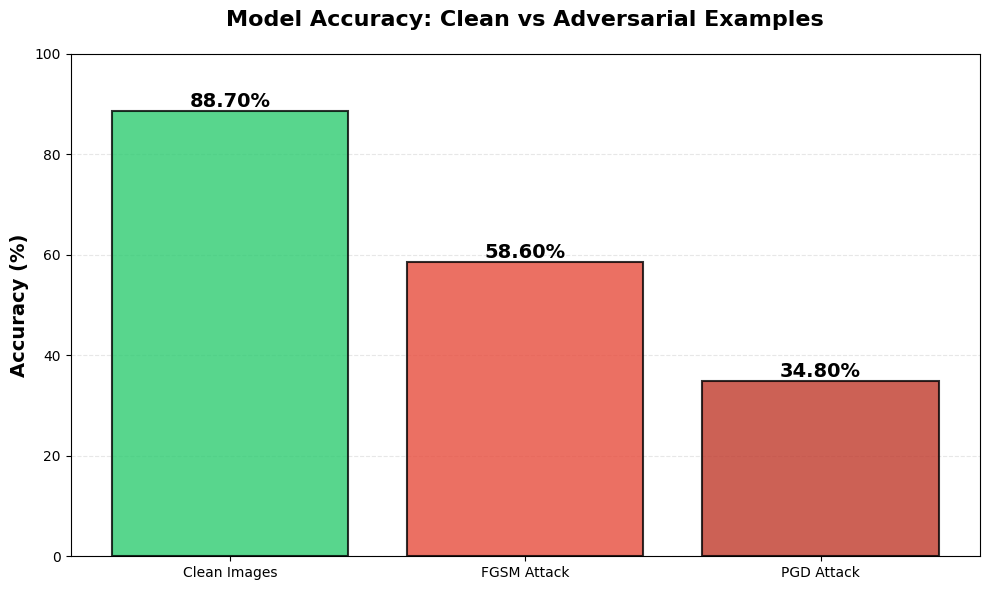

✅ Accuracy comparison chart generated!


In [11]:
# ============================================================
# Visualization 1: Accuracy Comparison Bar Chart
# ============================================================

import matplotlib.pyplot as plt

# Data for plotting
attack_types = ['Clean Images', 'FGSM Attack', 'PGD Attack']
accuracies = [clean_acc_subset, fgsm_accuracy, pgd_accuracy]
colors = ['#2ecc71', '#e74c3c', '#c0392b']

# Create bar chart
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(attack_types, accuracies, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)

# Add value labels on top of bars
for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{acc:.2f}%',
            ha='center', va='bottom', fontsize=14, fontweight='bold')

# Formatting
ax.set_ylabel('Accuracy (%)', fontsize=14, fontweight='bold')
ax.set_title('Model Accuracy: Clean vs Adversarial Examples', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_ylim(0, 100)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

print("✅ Accuracy comparison chart generated!")

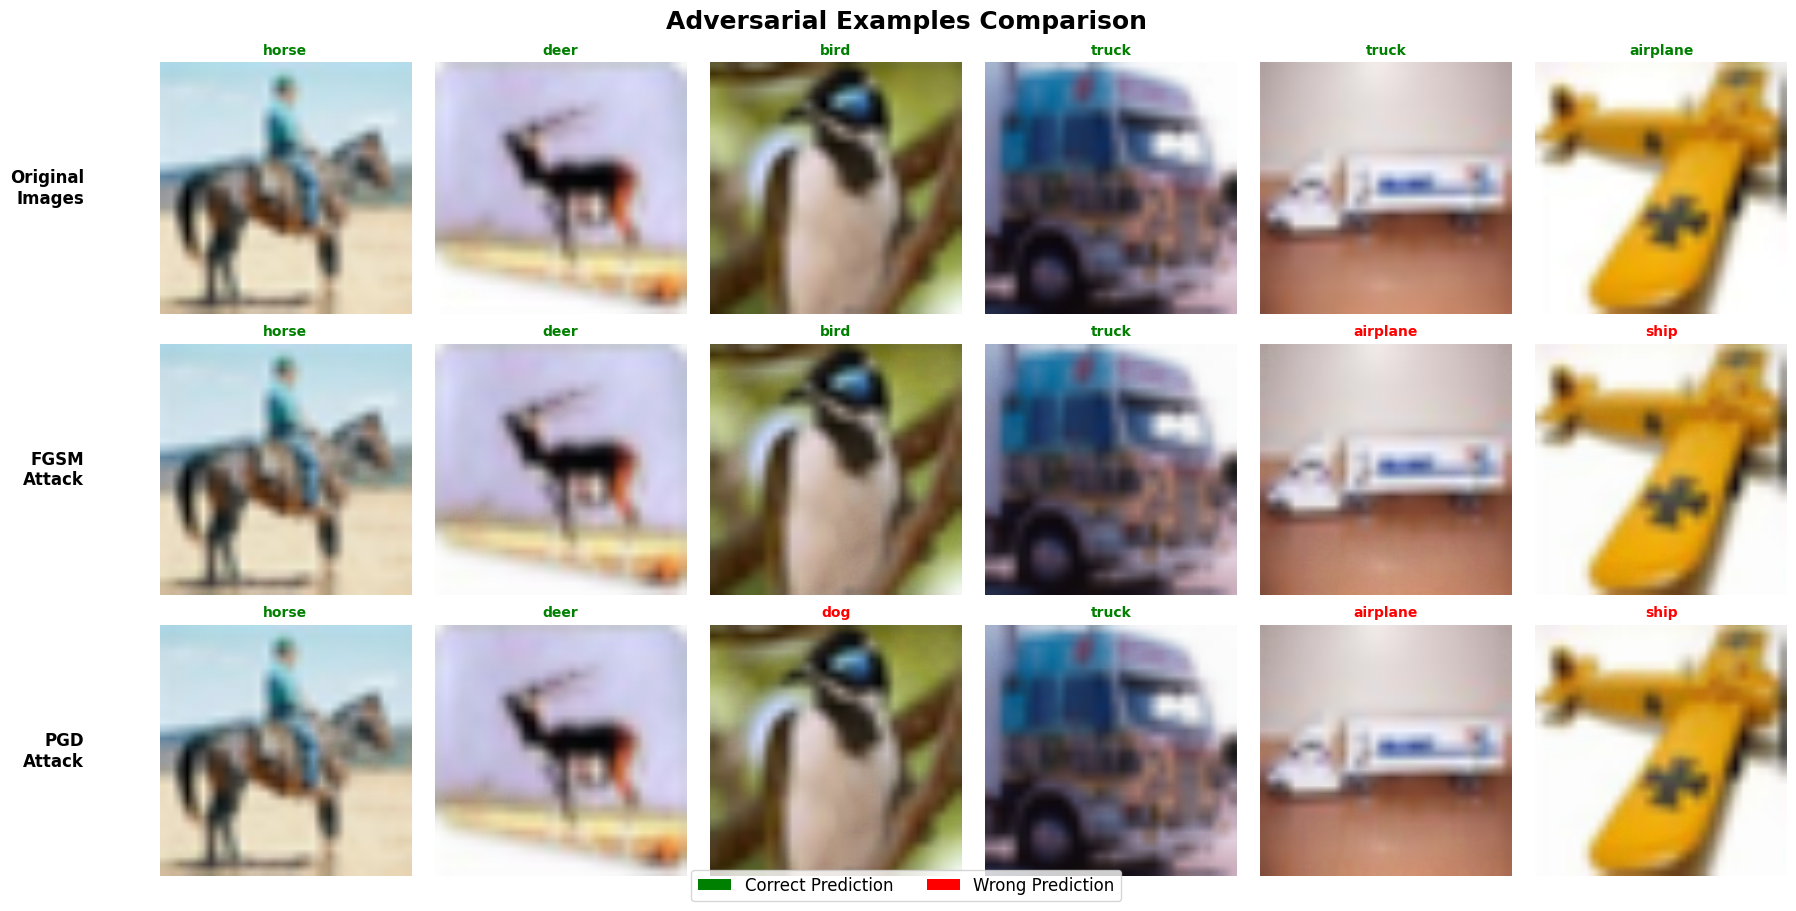

✅ Image comparison visualization generated!
🎯 True labels shown in green (correct) or red (misclassified)


In [12]:
# ============================================================
# Visualization 2: Original vs Adversarial Images
# ============================================================

def denormalize(tensor):
    """Convert normalized tensor back to [0,1] range for display"""
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return tensor * std + mean

# Select 6 random samples
np.random.seed(42)
sample_indices = np.random.choice(len(x_test_clean), 6, replace=False)

# Create figure with 3 rows (Clean, FGSM, PGD) and 6 columns
fig, axes = plt.subplots(3, 6, figsize=(18, 9))
fig.suptitle('Adversarial Examples Comparison', fontsize=18, fontweight='bold', y=0.98)

# Row labels
row_labels = ['Original\nImages', 'FGSM\nAttack', 'PGD\nAttack']

for col_idx, img_idx in enumerate(sample_indices):
    # Get images and label
    clean_img = x_test_clean[img_idx]
    fgsm_img = x_test_fgsm[img_idx]
    pgd_img = x_test_pgd[img_idx]
    true_label = y_test_labels[img_idx]
    
    # Get predictions
    with torch.no_grad():
        clean_tensor = torch.FloatTensor(clean_img).unsqueeze(0).to(device)
        fgsm_tensor = torch.FloatTensor(fgsm_img).unsqueeze(0).to(device)
        pgd_tensor = torch.FloatTensor(pgd_img).unsqueeze(0).to(device)
        
        pred_clean = model(clean_tensor).argmax(dim=1).item()
        pred_fgsm = model(fgsm_tensor).argmax(dim=1).item()
        pred_pgd = model(pgd_tensor).argmax(dim=1).item()
    
    # Denormalize images for display
    images = [clean_img, fgsm_img, pgd_img]
    predictions = [pred_clean, pred_fgsm, pred_pgd]
    
    for row_idx, (img, pred) in enumerate(zip(images, predictions)):
        # Convert to displayable format
        img_tensor = torch.FloatTensor(img)
        img_display = denormalize(img_tensor).permute(1, 2, 0).numpy()
        img_display = np.clip(img_display, 0, 1)
        
        ax = axes[row_idx, col_idx]
        ax.imshow(img_display)
        
        # Color code: green if correct, red if wrong
        is_correct = (pred == true_label)
        color = 'green' if is_correct else 'red'
        
        # Title with prediction
        title = f"{class_names[pred]}"
        ax.set_title(title, fontsize=10, color=color, fontweight='bold')
        ax.axis('off')
        
        # Add row labels on the left
        if col_idx == 0:
            ax.text(-0.3, 0.5, row_labels[row_idx], 
                   transform=ax.transAxes,
                   fontsize=12, fontweight='bold',
                   va='center', ha='right')

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='green', label='Correct Prediction'),
    Patch(facecolor='red', label='Wrong Prediction')
]
fig.legend(handles=legend_elements, loc='lower center', 
          ncol=2, fontsize=12, frameon=True, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
plt.show()

print("✅ Image comparison visualization generated!")
print(f"🎯 True labels shown in green (correct) or red (misclassified)")